# Plot ROI number quality threshold

- notebook aims to plot number of ROIs under different quality thresholds
- for experiment: 08.09.2025 and 23.11.2025
- for stimuli:
    - global chirp
    - local chirp
    - moving bars
- for conditions:
    - C1 and C2 if field had these conditions
    - C1 and DETA/NO if field had these conditions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Create access to djimaging database

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-10-30 13:26:24,514][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-10-30 13:26:24,608][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

## Activate Schema

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Global ChirpQI, number of ROIs

- concept of analysis
    - retrieve number of ROIs stimulated by chirp
    - quality filter:
        - C1 > 0.3
        - DETA/NO > 0.3
        - C1 & DETA/NO > 0.3
    - plot the ratios, how many ROIs persist with the quality filtering

## Retrieve Numbers

In [80]:
ChirpQI_20251023 = ChirpQI() & {"date": datetime.date(2025, 10, 23), "stim_name": "gChirp"}
ChirpQI_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,1,1,0.190383,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,2,1,0.268426,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,0.32174,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,0.348374,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,5,1,0.440524,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,0.312994,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,7,1,0.335758,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,0.335647,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,9,1,0.312693,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,0.381247,0.2


In [81]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording
rois_C1 = (ChirpQI_20251023 & {"cond2": "C1"}).fetch()
rois_C2 = (ChirpQI_20251023 & {"cond2": "C2"}).fetch()
rois_DETANO = (ChirpQI_20251023 & {"cond2": "DETANO"}).fetch()

print(f"Number of ROIs C1: {len(rois_C1)}")
print(f"Number of ROIs C2: {len(rois_C2)}")
print(f"Number of ROIs DETA/NO: {len(rois_DETANO)}")

Number of ROIs C1: 1340
Number of ROIs C2: 639
Number of ROIs DETA/NO: 701


In [82]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording and qidx > 0.3
rois_C1_filtered = (ChirpQI_20251023 & {"cond2": "C1"} & "qidx > 0.3").fetch()
rois_C2_filtered = (ChirpQI_20251023 & {"cond2": "C2"} & "qidx > 0.3").fetch()
rois_DETANO_filtered = (ChirpQI_20251023 & {"cond2": "DETANO"} & "qidx > 0.3").fetch()

print(f"Number of ROIs C1 (QI > 0.3): {len(rois_C1_filtered)}")
print(f"Number of ROIs C2 (QI > 0.3): {len(rois_C2_filtered)}")
print(f"Number of ROIs DETA/NO (QI > 0.3): {len(rois_DETANO_filtered)}")

Number of ROIs C1 (QI > 0.3): 893
Number of ROIs C2 (QI > 0.3): 514
Number of ROIs DETA/NO (QI > 0.3): 456


- plot these numbers in a bar plot

In [83]:
# Collect raw numbers in an array
# Nedded for plotting the raw numbers above the bars
numbers_of_fractions = [
    len(rois_C1),
    len(rois_C1_filtered),
    len(rois_C2),
    len(rois_C2_filtered),
    len(rois_DETANO),
    len(rois_DETANO_filtered)]
numbers_of_fractions

[1340, 893, 639, 514, 701, 456]

In [84]:
# Calculate fractions (percentages) used for plotting
# Using respective condition
fractions = [
    len(rois_C1)/len(rois_C1) * 100,
    len(rois_C1_filtered)/len(rois_C1) * 100,
    len(rois_C2)/len(rois_C2) * 100,
    len(rois_C2_filtered)/len(rois_C2) * 100,
    len(rois_DETANO)/len(rois_DETANO) * 100,
    len(rois_DETANO_filtered)/len(rois_DETANO) * 100]
fractions

[100.0, 66.64179104477613, 100.0, 80.43818466353677, 100.0, 65.04992867332382]

In [85]:
# Create X axis labels for the bar plot
# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 QI > 0.3", 
          "C2 unfiltered",
          "C2 QI > 0.3",
          "DETA/NO unfiltered",
          "DETA/NO QI > 0.3"]
labels

['C1 unfiltered',
 'C1 QI > 0.3',
 'C2 unfiltered',
 'C2 QI > 0.3',
 'DETA/NO unfiltered',
 'DETA/NO QI > 0.3']

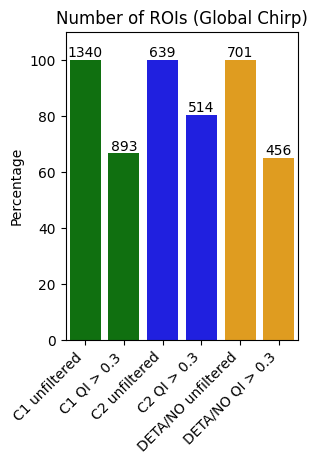

In [87]:
# Define custom colors for each bar
custom_colors = ['green', 'green', 'blue', 'blue', 'orange', 'orange']

# Create the plot
fig, axs = plt.subplots(1, 1, figsize=(3,4))
axs = sns.barplot(
    y=fractions,
    x=labels,
    hue=labels,                 # explicitly use hue
    palette=custom_colors,      # apply custom colors
    legend=False                # disable the automatic legend
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        height,                             # top of the bar
        str(number),                        # label to show
        ha='center',                        # horizontal alignment
        va='bottom',                        # vertical alignment
        fontsize=10
    )

# Adjust the plot
plt.title("Number of ROIs (Global Chirp)")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, 110)
plt.ylabel("Percentage", fontsize=10)

# Save the plot
plt.savefig("plots/20251023/gchirp/roi_number_filtering.png",
            dpi=300,
            bbox_inches="tight")

## Example for field XY3 and XY4

- fields were recorded pairwise
    - e.g., XY1/XY2 are from the same piece of the retina (in this case dorsal)
    - XY3/XY4 are from the same piece of the retina (in this case nasal)
- example how to compute the numbers for pairwise ROIs for the field XY3 and XY4 will be computed here

### XY3

In [41]:
# Retrieve # of ROIs in field XY3 from that date
rois_XY3 = (ChirpQI_20251023 & {"field": "XY3", "cond2": "C1"}).fetch("roi_id")
print(f"Number of ROIs in XY3 unfiltered: {len(rois_XY3)}")
print(f"Which ROIs: {rois_XY3}")

Number of ROIs in XY3 unfiltered: 113
Which ROIs: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113]


In [27]:
# Retrieve # of ROIs in field XY3 (QI > 0.3 in C1) from that date
rois_XY3_C1_filtered = (ChirpQI_20251023 & {"field": "XY3", "cond2": "C1"} & "qidx > 0.3").fetch("roi_id")
print(f"Number of ROIs in XY3 with C1 QI > 0.3: {len(rois_XY3_C1_filtered)}")
print(f"Which ROIs: {rois_XY3_C1_filtered}")

Number of ROIs in XY3 with C1 QI > 0.3: 51
Which ROIs: [  2   3  12  15  23  25  26  29  33  35  36  38  42  46  48  49  55  60
  64  65  74  75  76  78  80  81  83  85  86  89  90  91  92  93  94  95
  96  97  98  99 100 101 102 104 105 106 107 109 110 111 113]


In [29]:
# Retrieve # of ROIs in field XY3 (QI > 0.3 in C2) from that date
rois_XY3_C2_filtered = (ChirpQI_20251023 & {"field": "XY3", "cond2": "C2"} & "qidx > 0.3").fetch("roi_id")
print(f"Number of ROIs in XY3 with C2 QI > 0.3: {len(rois_XY3_C2_filtered)}")
print(f"Which ROIs: {rois_XY3_C2_filtered}")

Number of ROIs in XY3 with C2 QI > 0.3: 95
Which ROIs: [  1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  27  28  29  30  31  33  34  35  36  37  38  39  40
  42  43  44  45  46  47  48  49  50  51  52  53  54  56  57  58  59  60
  61  63  65  66  67  69  70  71  72  75  76  77  78  79  83  84  86  87
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 109 110 111 113]


In [38]:
# Retrieve ROIs which are common in both QI filtered conditions
common_rois = [int(x) for x in set(rois_XY3_C1_filtered) & set(rois_XY3_C2_filtered)]
print(f"Number of ROIs in C1 and C2 (QI > 0.3): {len(common_rois)}")
print(f"Which ROIs: {common_rois}")

Number of ROIs in C1 and C2 (QI > 0.3): 43
Which ROIs: [2, 3, 12, 15, 23, 29, 33, 35, 36, 38, 42, 46, 48, 49, 60, 65, 75, 76, 78, 83, 86, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 106, 107, 109, 110, 111, 113]


- Plot different fractions in a bar plot for that field

In [44]:
# Collect raw numbers in an array
# Nedded for plotting the raw numbers above the bars
numbers_of_fractions = [
    len(rois_XY3),
    len(rois_XY3_C1_filtered),
    len(rois_XY3_C2_filtered),
    len(common_rois)]
numbers_of_fractions

[113, 51, 95, 43]

In [45]:
# Calculate fractions (percentages) used for plotting
fractions = [
    len(rois_XY3)/len(rois_XY3) * 100,
    len(rois_XY3_C1_filtered)/len(rois_XY3) * 100,
    len(rois_XY3_C2_filtered)/len(rois_XY3) * 100,
    len(common_rois)/len(rois_XY3) * 100]
fractions

[100.0, 45.13274336283185, 84.070796460177, 38.05309734513274]

In [50]:
# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 QI > 0.3", 
          "C2 QI > 0.3",
          "C1 QI > 0.3 & C2 QI > 0.3"]
labels

['C1 unfiltered', 'C1 QI > 0.3', 'C2 QI > 0.3', 'C1 QI > 0.3 & C2 QI > 0.3']

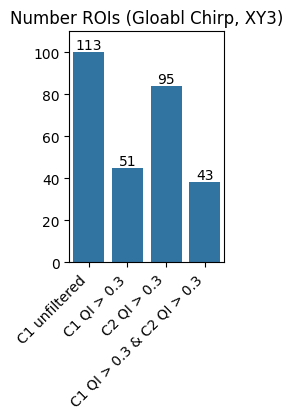

In [54]:
# Make the barplot
fig, axs = plt.subplots(1, 1, figsize=(2,3))
axs = sns.barplot(
    y=fractions,
    x=labels,
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2, # x position: center of the bar
        height,                            # y position: top of the bar
        str(number),                       # label to show
        ha='center',                       # horizontal alignment
        va='bottom')                       # vertical alignment, slightly above the bar
    
# Adjust the plot
plt.title("Number ROIs (Gloabl Chirp, XY3)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)

# Save the plot
plt.savefig("plots/20251023/gchirp/roi_number_filtering_XY3.png",
            dpi=300,
            bbox_inches="tight")

In [28]:
# Retrieve # of ROIs in field XY3 (QI > 0.3 in DETANO) from that date
rois_XY3_DETANO_filtered = (ChirpQI_20251023 & {"field": "XY3", "cond2": "DETANO"} & "qidx > 0.3").fetch("roi_id")
print(f"Number of ROIs in XY3 with DETANO QI > 0.3: {len(rois_XY3_DETANO_filtered)}")
print(f"Which ROIs: {rois_XY3_DETANO_filtered}")

Number of ROIs in XY3 with DETANO QI > 0.3: 0
Which ROIs: []


# Local ChirpQI, number of ROIs

In [64]:
ChirpQI_20251023 = ChirpQI() & {"date": datetime.date(2025, 10, 23), "stim_name": "lChirp"}
ChirpQI_20251023

[2025-10-30 14:51:31,749][WARNING]: Reconnecting to MySQL server.


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,1,1,0.253428,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,2,1,0.241509,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,3,1,0.383134,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,4,1,0.290725,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,5,1,0.316626,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,6,1,0.268894,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,7,1,0.258569,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,8,1,0.261686,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,9,1,0.368321,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,10,1,0.364482,0.2


In [65]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording
rois_C1 = (ChirpQI_20251023 & {"cond2": "C1"}).fetch()
rois_C2 = (ChirpQI_20251023 & {"cond2": "C2"}).fetch()
rois_DETANO = (ChirpQI_20251023 & {"cond2": "DETANO"}).fetch()

print(f"Number of ROIs C1: {len(rois_C1)}")
print(f"Number of ROIs C2: {len(rois_C2)}")
print(f"Number of ROIs DETA/NO: {len(rois_DETANO)}")

Number of ROIs C1: 1340
Number of ROIs C2: 639
Number of ROIs DETA/NO: 701


In [66]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording and qidx > 0.3
rois_C1_filtered = (ChirpQI_20251023 & {"cond2": "C1"} & "qidx > 0.3").fetch()
rois_C2_filtered = (ChirpQI_20251023 & {"cond2": "C2"} & "qidx > 0.3").fetch()
rois_DETANO_filtered = (ChirpQI_20251023 & {"cond2": "DETANO"} & "qidx > 0.3").fetch()

print(f"Number of ROIs C1 (QI > 0.3): {len(rois_C1_filtered)}")
print(f"Number of ROIs C2 (QI > 0.3): {len(rois_C2_filtered)}")
print(f"Number of ROIs DETA/NO (QI > 0.3): {len(rois_DETANO_filtered)}")

Number of ROIs C1 (QI > 0.3): 565
Number of ROIs C2 (QI > 0.3): 157
Number of ROIs DETA/NO (QI > 0.3): 225


In [67]:
# Collect raw numbers in an array
# Nedded for plotting the raw numbers above the bars
numbers_of_fractions = [
    len(rois_C1),
    len(rois_C1_filtered),
    len(rois_C2),
    len(rois_C2_filtered),
    len(rois_DETANO),
    len(rois_DETANO_filtered)]
numbers_of_fractions

[1340, 565, 639, 157, 701, 225]

In [68]:
# Calculate fractions (percentages) used for plotting
# Using respective condition
fractions = [
    len(rois_C1)/len(rois_C1) * 100,
    len(rois_C1_filtered)/len(rois_C1) * 100,
    len(rois_C2)/len(rois_C2) * 100,
    len(rois_C2_filtered)/len(rois_C2) * 100,
    len(rois_DETANO)/len(rois_DETANO) * 100,
    len(rois_DETANO_filtered)/len(rois_DETANO) * 100]
fractions

[100.0, 42.16417910447761, 100.0, 24.56964006259781, 100.0, 32.09700427960057]

In [69]:
# Create X axis labels for the bar plot
# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 QI > 0.3", 
          "C2 unfiltered",
          "C2 QI > 0.3",
          "DETA/NO unfiltered",
          "DETA/NO QI > 0.3"]
labels

['C1 unfiltered',
 'C1 QI > 0.3',
 'C2 unfiltered',
 'C2 QI > 0.3',
 'DETA/NO unfiltered',
 'DETA/NO QI > 0.3']

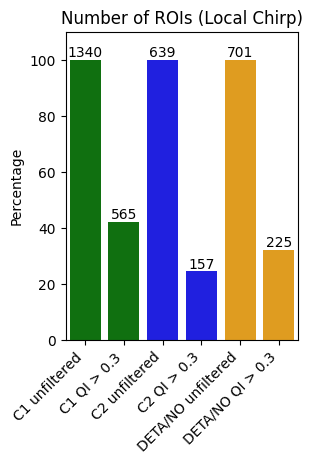

In [79]:
# Define custom colors for each bar
custom_colors = ['green', 'green', 'blue', 'blue', 'orange', 'orange']

# Create the plot
fig, axs = plt.subplots(1, 1, figsize=(3,4))
axs = sns.barplot(
    y=fractions,
    x=labels,
    hue=labels,                 # explicitly use hue
    palette=custom_colors,      # apply custom colors
    legend=False                # disable the automatic legend
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        height,                             # top of the bar
        str(number),                        # label to show
        ha='center',                        # horizontal alignment
        va='bottom',                        # vertical alignment
        fontsize=10
    )

# Adjust the plot
plt.title("Number of ROIs (Local Chirp)")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, 110)
plt.ylabel("Percentage", fontsize=10)

# Save the plot
plt.savefig("plots/20251023/lchirp/roi_number_filtering.png",
            dpi=300,
            bbox_inches="tight")

# Moving Bars, number of ROIs

In [90]:
OsDsIndexes_20251023 = OsDsIndexes() & {"date": datetime.date(2025, 10, 23), "stim_name": "movingbar"}
OsDsIndexes_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,ds_index direction selectivity index as resulting vector length (absolute of projection on complex exponential),ds_pvalue p-value indicating the percentile of the vector length in null distribution,pref_dir preferred direction,os_index orientation selectivity index in analogy to ds_index,os_pvalue analogous to ds_pvalue for orientation tuning,pref_or preferred orientation,on_off on off index based on time kernel,d_qi quality index for moving bar response,dir_component,time_component,time_component_dt,surrogate_v computed by projecting on time,surrogate_dsi DSI of surrogate v
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,1,1,0.518129,0.13,0.67739,0.255503,0.22,0.451553,-0.29,0.743992,=BLOB=,=BLOB=,0.128,=BLOB=,0.344454
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,2,1,0.189068,0.49,1.11137,0.230973,0.66,1.45222,0.24,0.698153,=BLOB=,=BLOB=,0.128,=BLOB=,0.199301
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,3,1,0.317163,0.56,0.2622,0.375889,0.73,0.859333,-0.15,0.794506,=BLOB=,=BLOB=,0.128,=BLOB=,0.283714
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,4,1,0.191293,0.43,1.92136,0.0583458,1.0,0.720485,-0.37,0.710519,=BLOB=,=BLOB=,0.128,=BLOB=,0.369453
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,5,1,0.240413,0.43,-2.0746,0.147013,0.27,1.24996,-0.37,0.767992,=BLOB=,=BLOB=,0.128,=BLOB=,0.336821
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,6,1,0.300926,0.06,-1.56135,0.291,0.16,1.61878,0.23,0.676463,=BLOB=,=BLOB=,0.128,=BLOB=,0.37714
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,7,1,0.362843,0.85,2.45805,0.183971,0.74,1.73276,-0.64,0.689501,=BLOB=,=BLOB=,0.128,=BLOB=,0.108139
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,8,1,0.196965,0.11,1.74406,0.332817,0.61,1.48851,-0.22,0.70035,=BLOB=,=BLOB=,0.128,=BLOB=,0.319335
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,9,1,0.0934428,0.54,2.05479,0.412961,0.09,1.19013,-0.68,0.633227,=BLOB=,=BLOB=,0.128,=BLOB=,0.263208
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,10,1,0.119732,0.07,-1.47908,0.316763,0.4,1.74549,-0.14,0.709296,=BLOB=,=BLOB=,0.128,=BLOB=,0.412726


In [91]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording
rois_C1 = (OsDsIndexes_20251023 & {"cond2": "C1"}).fetch()
rois_C2 = (OsDsIndexes_20251023 & {"cond2": "C2"}).fetch()
rois_DETANO = (OsDsIndexes_20251023 & {"cond2": "DETANO"}).fetch()

print(f"Number of ROIs C1: {len(rois_C1)}")
print(f"Number of ROIs C2: {len(rois_C2)}")
print(f"Number of ROIs DETA/NO: {len(rois_DETANO)}")

Number of ROIs C1: 1340
Number of ROIs C2: 639
Number of ROIs DETA/NO: 701


In [93]:
# Fetsch all ROIs which had either a C1, C2, or DETA/NO recording and d_qi > 0.6
rois_C1_filtered = (OsDsIndexes_20251023 & {"cond2": "C1"} & "d_qi > 0.6").fetch()
rois_C2_filtered = (OsDsIndexes_20251023 & {"cond2": "C2"} & "d_qi > 0.6").fetch()
rois_DETANO_filtered = (OsDsIndexes_20251023 & {"cond2": "DETANO"} & "d_qi > 0.6").fetch()

print(f"Number of ROIs C1 (QI > 0.6): {len(rois_C1_filtered)}")
print(f"Number of ROIs C2 (QI > 0.6): {len(rois_C2_filtered)}")
print(f"Number of ROIs DETA/NO (QI > 0.6): {len(rois_DETANO_filtered)}")

Number of ROIs C1 (QI > 0.6): 689
Number of ROIs C2 (QI > 0.6): 231
Number of ROIs DETA/NO (QI > 0.6): 300


In [94]:
# Collect raw numbers in an array
# Nedded for plotting the raw numbers above the bars
numbers_of_fractions = [
    len(rois_C1),
    len(rois_C1_filtered),
    len(rois_C2),
    len(rois_C2_filtered),
    len(rois_DETANO),
    len(rois_DETANO_filtered)]
numbers_of_fractions

[1340, 689, 639, 231, 701, 300]

In [95]:
# Calculate fractions (percentages) used for plotting
# Using respective condition
fractions = [
    len(rois_C1)/len(rois_C1) * 100,
    len(rois_C1_filtered)/len(rois_C1) * 100,
    len(rois_C2)/len(rois_C2) * 100,
    len(rois_C2_filtered)/len(rois_C2) * 100,
    len(rois_DETANO)/len(rois_DETANO) * 100,
    len(rois_DETANO_filtered)/len(rois_DETANO) * 100]
fractions

[100.0,
 51.417910447761194,
 100.0,
 36.15023474178404,
 100.0,
 42.796005706134096]

In [96]:
# Create X axis labels for the bar plot
# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 QI > 0.6", 
          "C2 unfiltered",
          "C2 QI > 0.6",
          "DETA/NO unfiltered",
          "DETA/NO QI > 0.6"]
labels

['C1 unfiltered',
 'C1 QI > 0.6',
 'C2 unfiltered',
 'C2 QI > 0.6',
 'DETA/NO unfiltered',
 'DETA/NO QI > 0.6']

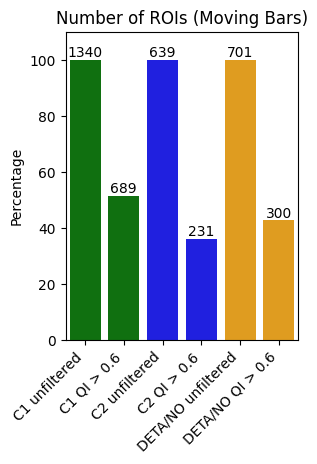

In [97]:
# Define custom colors for each bar
custom_colors = ['green', 'green', 'blue', 'blue', 'orange', 'orange']

# Create the plot
fig, axs = plt.subplots(1, 1, figsize=(3,4))
axs = sns.barplot(
    y=fractions,
    x=labels,
    hue=labels,                 # explicitly use hue
    palette=custom_colors,      # apply custom colors
    legend=False                # disable the automatic legend
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        height,                             # top of the bar
        str(number),                        # label to show
        ha='center',                        # horizontal alignment
        va='bottom',                        # vertical alignment
        fontsize=10
    )

# Adjust the plot
plt.title("Number of ROIs (Moving Bars)")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, 110)
plt.ylabel("Percentage", fontsize=10)

# Save the plot
plt.savefig("plots/20251023/mb/roi_number_filtering.png",
            dpi=300,
            bbox_inches="tight")

In [17]:
# Retrieve array with all dates
dates = (
    dj.U('date') & (ChirpQI())
).fetch('date')

# Check output
for date in dates:
    print(date)

2025-05-26
2025-06-12
2025-07-10


In [18]:
# Fetsch array with all fields
fields = (
    dj.U('field') & (ChirpQI())
).fetch('field')

# Remove field "XY" and sort the array
fields = fields[fields != "XY"]
fields = np.sort(fields)
fields

array(['XY1', 'XY10', 'XY2', 'XY3', 'XY4', 'XY5', 'XY6', 'XY7', 'XY8',
       'XY9'], dtype=object)

In [19]:
# Define empty array which should contain all the overlapping ROIs later
rois_overlap = []

# Itterate over the dates
for date in dates:

    # Itterate over the fields
    for field in fields:

        # Fetsch all ROIs which are C1, with qidx > 0.3
        rois_a = set((ChirpQI() & {"cond2": "C1", 
                                   "date": date, 
                                   "field": field} & "qidx > 0.3").fetch("roi_id"))

        # Fetsch all ROIs which are DETA/NO, with qidx > 0.3
        rois_b = set((ChirpQI() & {"cond2": "DETANO", 
                                   "date": date, 
                                   "field": field} & "qidx > 0.3").fetch("roi_id"))

        # Get an array with the number of ROIs which are in both
        common_rois_a_and_b = list(rois_a & rois_b)

        # Check output
        print(f"Field: {field}, Date: {date}, Number ROIs: {len(common_rois_a_and_b)}")

        # Append number of ROIs to array
        rois_overlap.append(len(common_rois_a_and_b))

# Calculate number of ROIs in both conditions and qidx > 0.3
number_rois_both_conditions = sum(rois_overlap)
print(f"Number ROIs ChirpQI > 0.3 both conditions: {number_rois_both_conditions}")

Field: XY1, Date: 2025-05-26, Number ROIs: 0
Field: XY10, Date: 2025-05-26, Number ROIs: 0
Field: XY2, Date: 2025-05-26, Number ROIs: 0
Field: XY3, Date: 2025-05-26, Number ROIs: 18
Field: XY4, Date: 2025-05-26, Number ROIs: 37
Field: XY5, Date: 2025-05-26, Number ROIs: 30
Field: XY6, Date: 2025-05-26, Number ROIs: 79
Field: XY7, Date: 2025-05-26, Number ROIs: 39
Field: XY8, Date: 2025-05-26, Number ROIs: 74
Field: XY9, Date: 2025-05-26, Number ROIs: 0
Field: XY1, Date: 2025-06-12, Number ROIs: 0
Field: XY10, Date: 2025-06-12, Number ROIs: 0
Field: XY2, Date: 2025-06-12, Number ROIs: 0
Field: XY3, Date: 2025-06-12, Number ROIs: 0
Field: XY4, Date: 2025-06-12, Number ROIs: 0
Field: XY5, Date: 2025-06-12, Number ROIs: 0
Field: XY6, Date: 2025-06-12, Number ROIs: 0
Field: XY7, Date: 2025-06-12, Number ROIs: 0
Field: XY8, Date: 2025-06-12, Number ROIs: 0
Field: XY9, Date: 2025-06-12, Number ROIs: 0
Field: XY1, Date: 2025-07-10, Number ROIs: 44
Field: XY10, Date: 2025-07-10, Number ROIs: 0


## Plotting

In [20]:
# Create array containing absolute numbers
numbers_of_fractions = [
    number_of_rois,
    c1_rois_filtered,
    detano_rois_filtered,
    number_rois_both_conditions]
numbers_of_fractions

[846, 603, 404, 336]

In [21]:
# Calculate percentages
fractions = [number_of_rois / number_of_rois * 100, 
             c1_rois_filtered / number_of_rois * 100,
             detano_rois_filtered / number_of_rois * 100,
             number_rois_both_conditions / number_of_rois * 100]

# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 ChirpQI > 0.3", 
          "DETA/NO ChirpQI > 0.3",
          "C1 ChirpQI > 0.3 & DETA/NO ChirpQI > 0.3"]

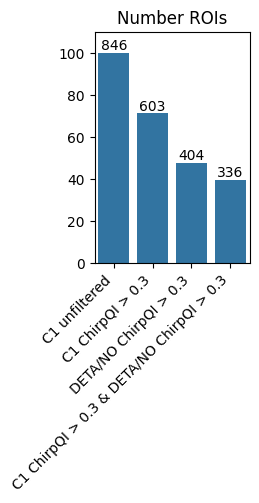

In [22]:
# Make the barplot
fig, axs = plt.subplots(1, 1, figsize=(2,3))
axs = sns.barplot(
    y=fractions,
    x=labels,
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2, # x position: center of the bar
        height,                            # y position: top of the bar
        str(number),                       # label to show
        ha='center',                       # horizontal alignment
        va='bottom')                       # vertical alignment, slightly above the bar
    
# Adjust the plot
plt.title("Number ROIs")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)

# Save the plot
plt.savefig("plots/roi_number_chirpqi_filtering.png",
            dpi=600,
            bbox_inches="tight")

# Moving Bars, number of ROIs
- same analysis, just moving bars instead of chirp
- threshold > 0.5

## Retrieve numbers

In [23]:
OsDsIndexes()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,ds_index direction selectivity index as resulting vector length (absolute of projection on complex exponential),ds_pvalue p-value indicating the percentile of the vector length in null distribution,pref_dir preferred direction,os_index orientation selectivity index in analogy to ds_index,os_pvalue analogous to ds_pvalue for orientation tuning,pref_or preferred orientation,on_off on off index based on time kernel,d_qi quality index for moving bar response,dir_component,time_component,time_component_dt,surrogate_v computed by projecting on time,surrogate_dsi DSI of surrogate v
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,1,1,0.332048,0.06,-1.71109,0.137961,0.33,2.38679,-0.23,0.667817,=BLOB=,=BLOB=,0.128,=BLOB=,0.423561
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,2,1,0.506292,0.02,-2.10308,0.11989,0.91,1.05204,-0.36,0.788609,=BLOB=,=BLOB=,0.128,=BLOB=,0.53199
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,3,1,0.411816,0.14,-2.44159,0.134719,0.96,2.45371,-0.11,0.722388,=BLOB=,=BLOB=,0.128,=BLOB=,0.378891
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,4,1,0.211053,0.58,3.11599,0.224537,0.91,0.885654,-0.54,0.683501,=BLOB=,=BLOB=,0.128,=BLOB=,0.231086
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,5,1,0.519728,0.07,-2.34259,0.348073,0.38,0.585672,0.08,0.690169,=BLOB=,=BLOB=,0.128,=BLOB=,0.372265
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,6,1,0.0924344,0.24,-0.198883,0.383195,0.48,0.0295907,-0.31,0.631704,=BLOB=,=BLOB=,0.128,=BLOB=,0.344803
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,7,1,0.498549,0.02,-2.37765,0.205384,0.55,2.59547,-0.31,0.713045,=BLOB=,=BLOB=,0.128,=BLOB=,0.512115
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,8,1,0.509254,0.02,-2.45164,0.0717104,0.97,0.0817144,-0.35,0.822728,=BLOB=,=BLOB=,0.128,=BLOB=,0.500441
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,9,1,0.165916,0.76,1.88261,0.339158,0.39,2.7123,0.68,0.717441,=BLOB=,=BLOB=,0.128,=BLOB=,0.176952
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,10,1,0.418335,0.12,-1.41873,0.244818,0.64,1.9429,-0.17,0.636709,=BLOB=,=BLOB=,0.128,=BLOB=,0.442509


In [24]:
# Fetsch all ROIs which had a C1 condition
all_rois = (OsDsIndexes() & {"cond2": "C1"}).fetch()

# ROIs at 2025, 6, 12 only had C1 and no DETA/NO condition
# Number of ROIs for this date should be removed here from number of all ROIs
rois_date_excluded = (OsDsIndexes() & 
                      {"date": datetime.date(2025, 6, 12), "cond2": "C1"}).fetch()

# Calculate how many ROIs
number_of_rois = len(all_rois) - len(rois_date_excluded)
print(f"Number of ROIs: {number_of_rois}")

Number of ROIs: 846


In [25]:
# Fetsch ROIs with d_qi > 0.5 in C1
c1_filtered_mb_qi = (OsDsIndexes() & {"cond2": "C1"} & "d_qi > 0.5").fetch()

# ROIs at 2025, 6, 12 only had C1 and no DETA/NO condition
# Number of ROIs for this date should be removed here from number of all ROIs
rois_date_excluded = (OsDsIndexes() & 
                      {"date": datetime.date(2025, 6, 12), "cond2": "C1"} &
                      "d_qi > 0.5").fetch()

# Calculate, how many ROIs
c1_rois_filtered = len(c1_filtered_mb_qi) - len(rois_date_excluded)
print(f"Number of ROIs, MBQI (C1) > 0.5: {c1_rois_filtered}")

Number of ROIs, MBQI (C1) > 0.5: 732


In [26]:
# Fetsch ROIs with d_qi > 0.5 in DETA/NO
detano_filtered_mb_qi = (OsDsIndexes() & {"cond2": "DETANO"} & "d_qi > 0.5").fetch()

# Calculate, how many ROIs
detano_rois_filtered = len(detano_filtered_mb_qi)
print(f"Number of ROIs, MBQI(DETANO) > 0.5: {detano_rois_filtered}")

Number of ROIs, MBQI(DETANO) > 0.5: 447


In [27]:
# Define empty array which should contain all the overlapping ROIs later
rois_overlap = []

# Itterate over the dates
for date in dates:

    # Itterate over the fields
    for field in fields:

        # Fetsch all ROIs which are C1, with d_qi > 0.5
        rois_a = set((OsDsIndexes() & 
                      {"cond2": "C1",
                       "date": date,
                       "field": field} & "d_qi > 0.5").fetch("roi_id"))

        # Fetsch all ROIs which are DETA/NO, with d_qi > 0.5
        rois_b = set((OsDsIndexes() & 
                      {"cond2": "DETANO",
                       "date": date,
                       "field": field} & "d_qi > 0.5").fetch("roi_id"))

        # Get an array with the number of ROIs which are in both
        common_rois_a_and_b = list(rois_a & rois_b)

        # Check output
        print(f"Field: {field}, Date: {date}, Number ROIs: {len(common_rois_a_and_b)}")

        # Append number of ROIs to array
        rois_overlap.append(len(common_rois_a_and_b))

# Calculate number of ROIs in both conditions and d_qi > 0.5
number_rois_both_conditions = sum(rois_overlap)
print(f"Number ROIs MBQI > 0.5 both conditions: {number_rois_both_conditions}")

Field: XY1, Date: 2025-05-26, Number ROIs: 0
Field: XY10, Date: 2025-05-26, Number ROIs: 0
Field: XY2, Date: 2025-05-26, Number ROIs: 0
Field: XY3, Date: 2025-05-26, Number ROIs: 59
Field: XY4, Date: 2025-05-26, Number ROIs: 40
Field: XY5, Date: 2025-05-26, Number ROIs: 48
Field: XY6, Date: 2025-05-26, Number ROIs: 31
Field: XY7, Date: 2025-05-26, Number ROIs: 72
Field: XY8, Date: 2025-05-26, Number ROIs: 67
Field: XY9, Date: 2025-05-26, Number ROIs: 0
Field: XY1, Date: 2025-06-12, Number ROIs: 0
Field: XY10, Date: 2025-06-12, Number ROIs: 0
Field: XY2, Date: 2025-06-12, Number ROIs: 0
Field: XY3, Date: 2025-06-12, Number ROIs: 0
Field: XY4, Date: 2025-06-12, Number ROIs: 0
Field: XY5, Date: 2025-06-12, Number ROIs: 0
Field: XY6, Date: 2025-06-12, Number ROIs: 0
Field: XY7, Date: 2025-06-12, Number ROIs: 0
Field: XY8, Date: 2025-06-12, Number ROIs: 0
Field: XY9, Date: 2025-06-12, Number ROIs: 0
Field: XY1, Date: 2025-07-10, Number ROIs: 46
Field: XY10, Date: 2025-07-10, Number ROIs: 0


## Plotting

In [28]:
# Create array containing absolute numbers
numbers_of_fractions = [
    number_of_rois,
    c1_rois_filtered,
    detano_rois_filtered,
    number_rois_both_conditions]
numbers_of_fractions

[846, 732, 447, 404]

In [29]:
# Calculate percentages
fractions = [number_of_rois / number_of_rois * 100, 
             c1_rois_filtered / number_of_rois * 100,
             detano_rois_filtered / number_of_rois * 100,
             number_rois_both_conditions / number_of_rois * 100]

# Make labels for plot
labels = ["C1 unfiltered", 
          "C1 MBQI > 0.5", 
          "DETA/NO MBQI > 0.5",
          "C1 MBQI > 0.5 & DETA/NO MBQI > 0.5"]

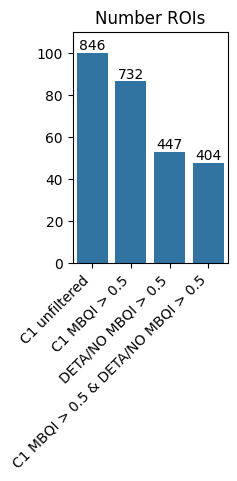

In [30]:
# Make the barplot
fig, axs = plt.subplots(1, 1, figsize=(2,3))
axs = sns.barplot(
    y=fractions,
    x=labels,
)

# Annotate absolute number to the bars
for bar, number in zip(axs.patches, numbers_of_fractions):
    height = bar.get_height()
    axs.text(
        bar.get_x() + bar.get_width() / 2, # x position: center of the bar
        height,                            # y position: top of the bar
        str(number),                       # label to show
        ha='center',                       # horizontal alignment
        va='bottom')                       # vertical alignment, slightly above the bar
    
# Adjust the plot
plt.title("Number ROIs")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)

# Save the plot
plt.savefig("plots/roi_number_mbqi_filtering.png",
            dpi=600,
            bbox_inches="tight")